In [2]:
import os
import numpy as np
import pandas as pd

data_dir = "/content/"

print("Files available in data directory:")
if os.path.exists(data_dir):
    print(os.listdir(data_dir))
else:
    print(f"{data_dir} not found. Upload your files or update data_dir.")

Files available in data directory:
['.config', 'train.csv', 'Sample.csv', 'test.csv', 'sample_data']


### Importing necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model    import LogisticRegression, SGDClassifier
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report,accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

### Loading Datasets

In [4]:
train_path = f"{data_dir}/train.csv"
test_path = f"{data_dir}/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (198000, 15)
Test shape: (102000, 14)


In [ ]:
y = train["label"]

#### Dataset Overview

In [ ]:
print(train.info())
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (t

In [ ]:
train['emoticon_1'].unique()

array([ 0,  1, 15,  2,  3,  4,  5, 11,  6,  7,  8, 24, 12, 17, 14, 13,  9,
       10, 20, 16, 25, 18, 21, 19, 23, 36, 22, 28, 27, 33, 30, 46, 32, 47,
       31, 39])

In [ ]:
train['emoticon_2'].unique()

array([ 0,  1,  2,  4,  3,  5,  8,  6, 11,  7])

In [ ]:
train['emoticon_3'].unique()

array([ 0,  1,  2,  4,  3,  6,  5, 10,  7, 11,  9, 14, 17, 13,  8, 12])

In [ ]:
train['race'].unique()

array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

In [ ]:
train['gender'].unique()

array([nan, 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

In [ ]:
train['religion'].unique()

array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

In [ ]:
print("Missing values:")            #finding out missing values
print(train.isnull().sum())

Missing values:
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


In [ ]:
print(train.head)           #getting an overview of the data
print(test.head)

<bound method NDFrame.head of                             created_date  post_id  emoticon_1  emoticon_2  \
0       2024-01-18 08:43:57.397508+00:00       73           0           0   
1       2024-03-24 21:43:11.490017+00:00       39           0           0   
2       2024-04-24 20:32:17.014931+00:00       31           0           1   
3       2023-05-28 22:00:14.214527+00:00       39           0           0   
4       2023-09-09 23:12:05.689498+00:00       39           0           0   
...                                  ...      ...         ...         ...   
197995  2023-02-04 10:39:30.581185+00:00       39           0           0   
197996  2023-11-01 17:16:51.337370+00:00       72           0           0   
197997  2024-03-09 15:46:22.542539+00:00       72           0           0   
197998  2023-08-07 17:23:40.163756+00:00       72           0           1   
197999  2023-08-26 19:36:00.380158+00:00       72           0           0   

        emoticon_3  upvote  downvote  if_1  i

In [ ]:
print(train.describe())          #statistical summary of dataset

             post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean       68.447429       0.279768       0.048338       0.121071   
std        27.948390       1.023234       0.258477       0.481013   
min        20.000000       0.000000       0.000000       0.000000   
25%        39.000000       0.000000       0.000000       0.000000   
50%        72.000000       0.000000       0.000000       0.000000   
75%        72.000000       0.000000       0.000000       0.000000   
max       129.000000      47.000000      11.000000      17.000000   

              upvote       downvote           if_1           if_2  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        2.607975       0.666394       1.906152       7.956212   
std         5.054763       2.044335      25.635752      14.839464   
min         0.000000       0.000000       0.000000       3.000000   
25%         0.000000       0.0000

In [ ]:
train1=train.copy()
test1=test.copy()

In [ ]:
cols = ["upvote", "downvote", "emoticon_1", "emoticon_2", "emoticon_3"]

print(train1[cols].describe())

              upvote       downvote     emoticon_1     emoticon_2  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        2.607975       0.666394       0.279768       0.048338   
std         5.054763       2.044335       1.023234       0.258477   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         1.000000       0.000000       0.000000       0.000000   
75%         3.000000       1.000000       0.000000       0.000000   
max       201.000000     107.000000      47.000000      11.000000   

          emoticon_3  
count  198000.000000  
mean        0.121071  
std         0.481013  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max        17.000000  


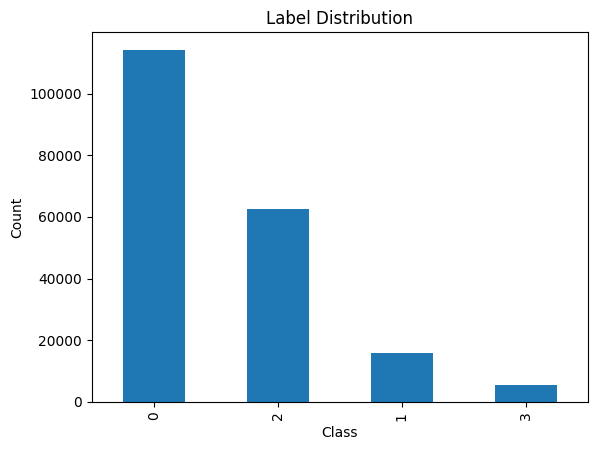

In [ ]:
train1["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

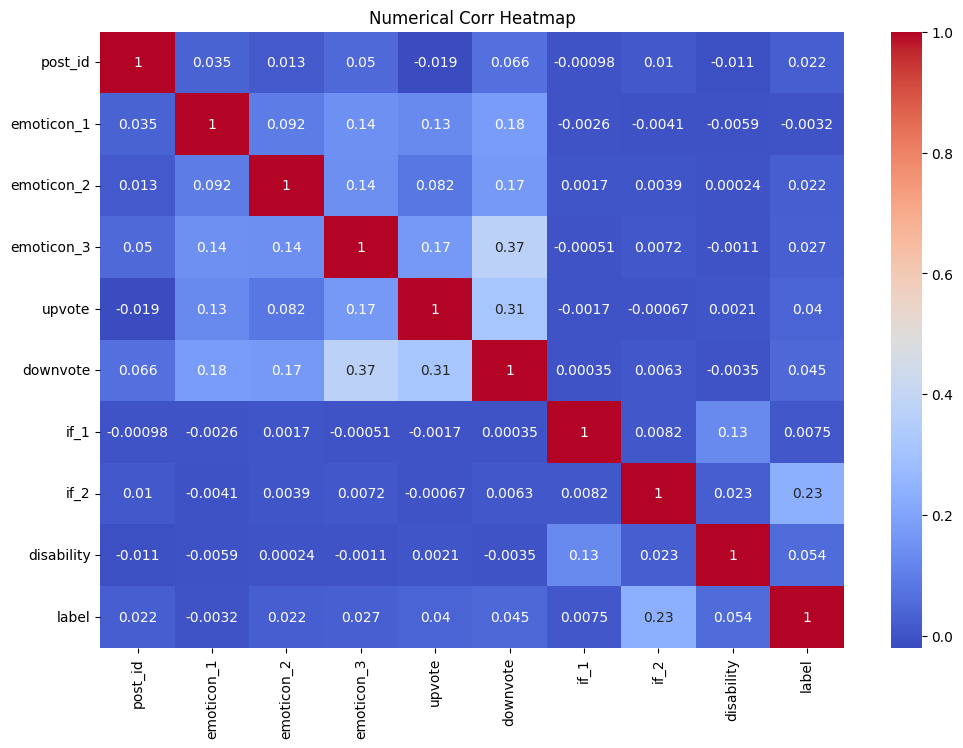

In [ ]:
plt.figure(figsize=(12,8))
corr=train1.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Numerical Corr Heatmap")
plt.show()

#### Cleaning of content column of dataset

In [ ]:
def clean_text(text):
  text=str(text).lower()
  text=re.sub(r"http\S+WWW\S+"," url ",text)     #converts links to url
  text=re.sub(r"[a-z0-9\s?!]"," ",text)    #removes special characters
  text=re.sub(r"\s"," ",text).strip()      #removes excess spaces
  return text

In [ ]:
train1["comment_clean"] = train1["comment"].apply(clean_text)
train1["comment_length"] = train1["comment_clean"].astype(str).apply(len)
test1["comment_clean"]  = test1["comment"].apply(clean_text)
test1["comment_length"] = test1["comment_clean"].astype(str).apply(len)

In [ ]:
for col in ["race", "religion", "gender"]:
    print( col)
    print(train1[col].value_counts().head())

race
race
none     39682
white     5486
black     3869
other     1654
asian     1263
Name: count, dtype: int64
religion
religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
Name: count, dtype: int64
gender
gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64


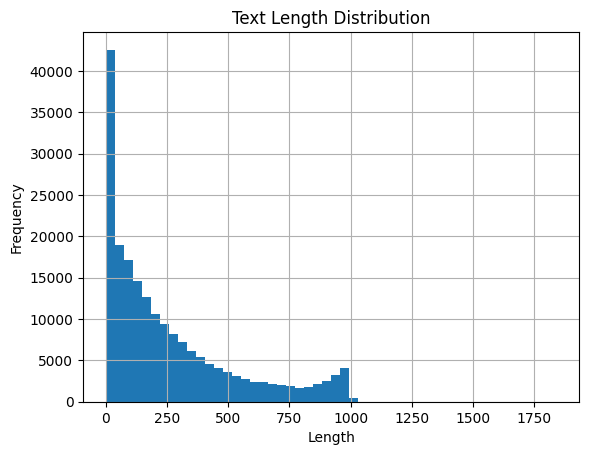

In [ ]:
train1["comment_length"].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(train1["comment"].head(5))       #getting an ovweview of comment column

0    She might be a bright spot for a party keou on...
1    Under Alaska law, a non-tribal member is not b...
2    in the future please spare me your strawman dr...
3    PS: That should have been "rot" instead of "co...
4    Today, the confederate flag...tomorrow, the na...
Name: comment, dtype: object


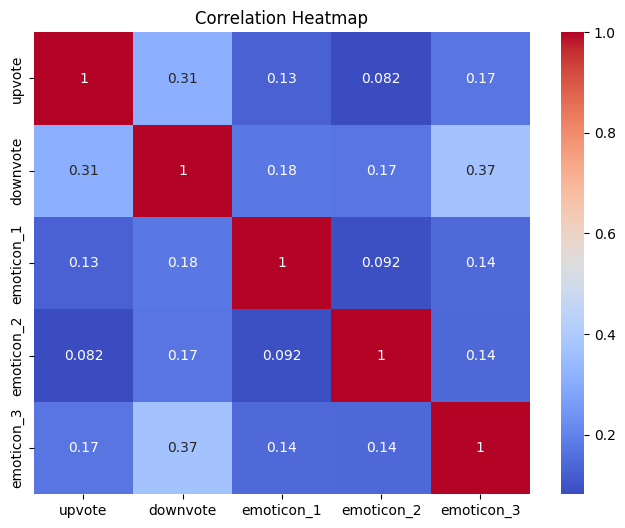

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(train1[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

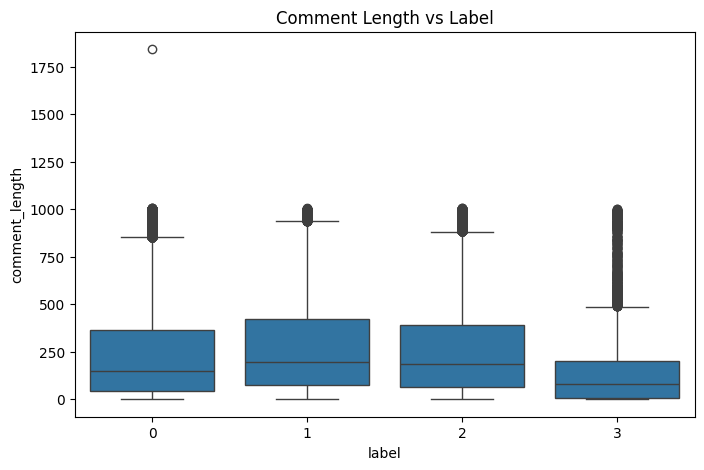

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="comment_length", data=train1)
plt.title("Comment Length vs Label")
plt.show()

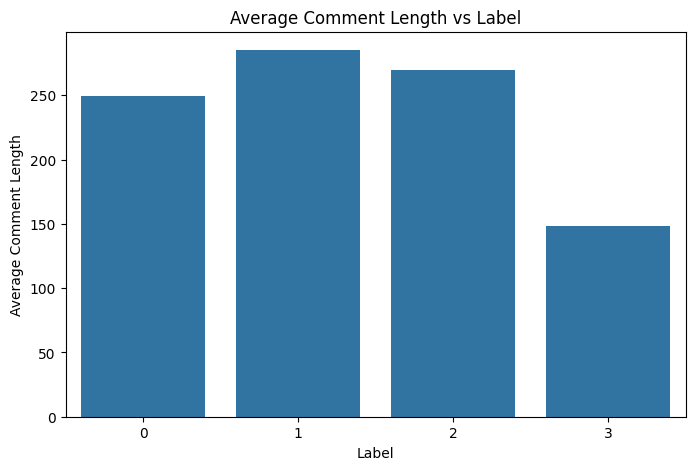

In [ ]:
plt.figure(figsize=(8,5))

avg_len = train1.groupby("label")["comment_length"].mean()

sns.barplot(x=avg_len.index, y=avg_len.values)

plt.xlabel("Label")
plt.ylabel("Average Comment Length")
plt.title("Average Comment Length vs Label")

plt.show()

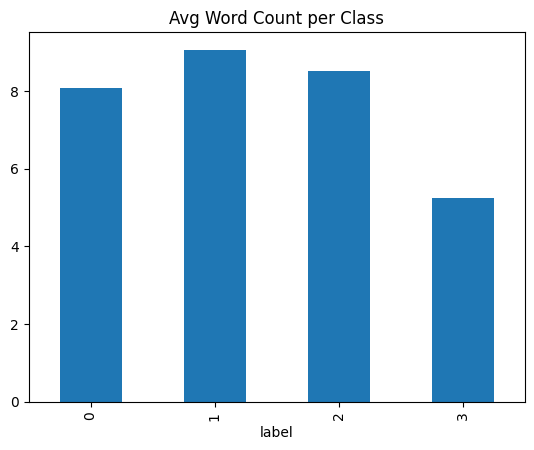

In [ ]:
train1["word_count"] = train1["comment_clean"].apply(lambda x: len(x.split()))

train1.groupby("label")["word_count"].mean().plot(kind="bar")
plt.title("Avg Word Count per Class")
plt.show()

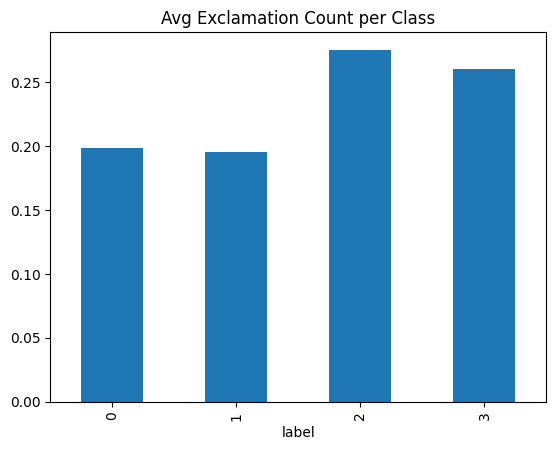

In [ ]:
train1["exclamation_count"] = train1["comment"].astype(str).apply(lambda x: x.count("!"))

train1.groupby("label")["exclamation_count"].mean().plot(kind="bar")
plt.title("Avg Exclamation Count per Class")
plt.show()

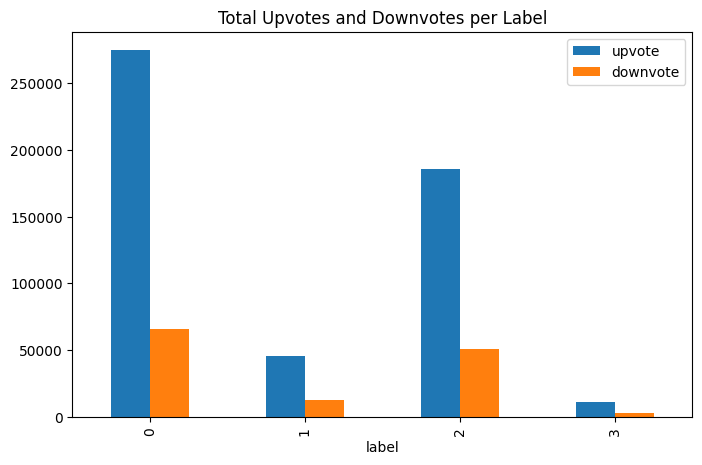

In [ ]:
train1.groupby("label")[["upvote","downvote"]].sum().plot(kind="bar", figsize=(8,5))
plt.title("Total Upvotes and Downvotes per Label")
plt.show()

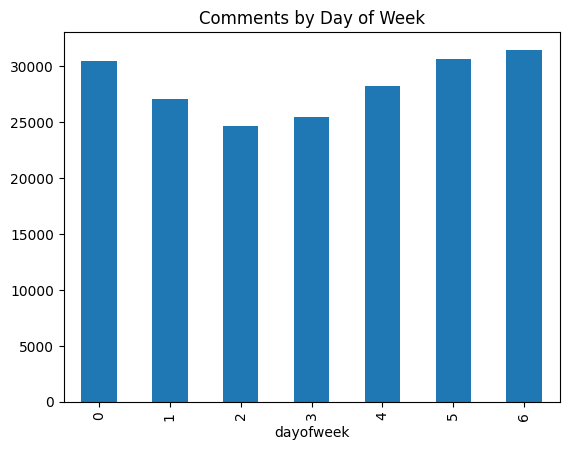

In [ ]:
train1["created_date"] = pd.to_datetime(train1["created_date"], errors="coerce")
train1["dayofweek"] = train1["created_date"].dt.dayofweek

train1["dayofweek"].value_counts().sort_index().plot(kind="bar")
plt.title("Comments by Day of Week")
plt.show()

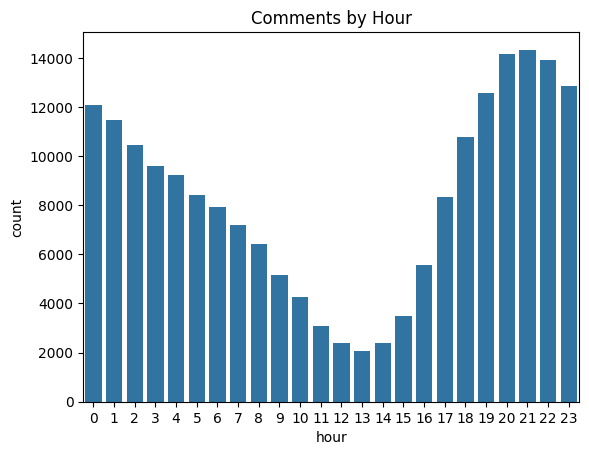

In [ ]:
dt = pd.to_datetime(train1["created_date"], errors="coerce")
train1["hour"] = dt.dt.hour

sns.countplot(x="hour", data=train1)
plt.title("Comments by Hour")
plt.show()

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)  #converts Url to tokens
    text = re.sub(r"[^a-z0-9\s!?]", " ", text)       #any special character is removed and converted into blank space
    text = re.sub(r"\s+", " ", text).strip()         #removes excess space
    return text

train["comment_clean"] = train["comment"].apply(clean_text)
test["comment_clean"]  = test["comment"].apply(clean_text)

#### Handling missing data and none

In [ ]:
for col in ["race", "religion", "gender"]:
    train[col] = train[col].replace(["none"], "unknown")
    test[col]  = test[col].replace(["none"], "unknown")
    train[col] = train[col].fillna("missing")
    test[col]  = test[col].fillna("missing")

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   created_date   198000 non-null  object
 1   post_id        198000 non-null  int64 
 2   emoticon_1     198000 non-null  int64 
 3   emoticon_2     198000 non-null  int64 
 4   emoticon_3     198000 non-null  int64 
 5   upvote         198000 non-null  int64 
 6   downvote       198000 non-null  int64 
 7   if_1           198000 non-null  int64 
 8   if_2           198000 non-null  int64 
 9   race           198000 non-null  object
 10  religion       198000 non-null  object
 11  gender         198000 non-null  object
 12  disability     198000 non-null  bool  
 13  comment        197999 non-null  object
 14  label          198000 non-null  int64 
 15  comment_clean  198000 non-null  object
dtypes: bool(1), int64(9), object(6)
memory usage: 22.8+ MB


#### Encoding Categorical Columns

In [ ]:
for col in ["race", "religion", "gender"]:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]], ignore_index=True))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

#### Feature Engineering

In [ ]:
def create_features(df):
    text = df["comment"].astype(str)
    clean = df["comment_clean"].astype(str)          ##cleaning the text

    df["comment_length"] = text.apply(len)           ##finding length of comment
    df["word_count"] = clean.apply(lambda x: len(x.split()))
    df["avg_word_length"] = clean.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    df["unique_word_ratio"] = clean.apply(
        lambda x: len(set(x.split())) / (len(x.split()) + 1)
    )
    df["char_per_word"] = df["comment_length"] / (df["word_count"] + 1)

    df["exclamation_count"] = text.apply(lambda x: x.count("!"))
    df["question_count"] = text.apply(lambda x: x.count("?"))
    df["caps_ratio"] = text.apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
    )

    df["total_votes"] = df["upvote"] + df["downvote"]
    df["vote_ratio"] = df["upvote"] / (df["downvote"] + 1)
    df["vote_diff"] = df["upvote"] - df["downvote"]

    df["log_upvote"] = np.log1p(df["upvote"])
    df["log_downvote"] = np.log1p(df["downvote"])

    df["total_emoticons"] = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]
    df["emoticon_ratio"] = df["emoticon_1"] / (df["emoticon_3"] + 1)
    df["has_emoticon"] = (df["total_emoticons"] > 0).astype(int)

    return df

In [ ]:
train = create_features(train)
test  = create_features(test)

#### Post-level aggregated features like number of comments, average upvotes, downvotes, and comment length for each post.

In [ ]:
post_agg = train.groupby("post_id").agg(
    post_size         = ("post_id", "count"),
    post_avg_upvote   = ("upvote", "mean"),
    post_avg_downvote = ("downvote", "mean"),
    post_avg_length   = ("comment_length", "mean"),
).reset_index()

for df in [train, test]:
    df = df.merge(post_agg, on="post_id", how="left")
    for col in ["post_size", "post_avg_upvote", "post_avg_downvote", "post_avg_length"]:
        df[col] = df[col].fillna(df[col].median() if col in df else 0)

train = train.merge(post_agg, on="post_id", how="left")
test  = test.merge(post_agg, on="post_id", how="left")

for col in ["post_size", "post_avg_upvote", "post_avg_downvote", "post_avg_length"]:
    train[col] = train[col].fillna(0)
    test[col]  = test[col].fillna(train[col].median())

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   created_date       198000 non-null  object 
 1   post_id            198000 non-null  int64  
 2   emoticon_1         198000 non-null  int64  
 3   emoticon_2         198000 non-null  int64  
 4   emoticon_3         198000 non-null  int64  
 5   upvote             198000 non-null  int64  
 6   downvote           198000 non-null  int64  
 7   if_1               198000 non-null  int64  
 8   if_2               198000 non-null  int64  
 9   race               198000 non-null  int64  
 10  religion           198000 non-null  int64  
 11  gender             198000 non-null  int64  
 12  disability         198000 non-null  bool   
 13  comment            197999 non-null  object 
 14  label              198000 non-null  int64  
 15  comment_clean      198000 non-null  object 
 16  co

In [ ]:
for df in [train, test]:                                      ##Extracting Date Features
    dt = pd.to_datetime(df["created_date"], errors="coerce")
    df["hour"]       = dt.dt.hour.fillna(-1).astype(int)
    df["dayofweek"]  = dt.dt.dayofweek.fillna(-1).astype(int)
    df["month"]      = dt.dt.month.fillna(-1).astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)


#### TF-IDF Feature Extraction (Word & Character Level)

In [ ]:
tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),
    stop_words="english",
    sublinear_tf=True,
    min_df=3,
    dtype=np.float32,
)

tfidf_char = TfidfVectorizer(
    max_features=30000,
    ngram_range=(2, 4),
    analyzer="char_wb",
    sublinear_tf=True,
    min_df=5,
    dtype=np.float32,
)

X_word_train = tfidf_word.fit_transform(train["comment_clean"])
X_word_test  = tfidf_word.transform(test["comment_clean"])

X_char_train = tfidf_char.fit_transform(train["comment_clean"])
X_char_test  = tfidf_char.transform(test["comment_clean"])

In [ ]:
print("Word TF-IDF shape:", X_word_train.shape)
print("Char TF-IDF shape:", X_char_train.shape)

Word TF-IDF shape: (198000, 30000)
Char TF-IDF shape: (198000, 30000)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 40 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   created_date       198000 non-null  object 
 1   post_id            198000 non-null  int64  
 2   emoticon_1         198000 non-null  int64  
 3   emoticon_2         198000 non-null  int64  
 4   emoticon_3         198000 non-null  int64  
 5   upvote             198000 non-null  int64  
 6   downvote           198000 non-null  int64  
 7   if_1               198000 non-null  int64  
 8   if_2               198000 non-null  int64  
 9   race               198000 non-null  int64  
 10  religion           198000 non-null  int64  
 11  gender             198000 non-null  int64  
 12  disability         198000 non-null  bool   
 13  comment            197999 non-null  object 
 14  label              198000 non-null  int64  
 15  comment_clean      198000 non-null  object 
 16  co

In [ ]:
drop_cols_train = ["comment", "comment_clean", "label", "created_date"]
drop_cols_test  = ["comment", "comment_clean", "created_date"]

X_num_train = train.drop(columns=drop_cols_train)
X_num_test  = test.drop(columns=drop_cols_test)

X_num_train, X_num_test = X_num_train.align(X_num_test, join="left", axis=1, fill_value=0)

X_num_train = X_num_train.fillna(0).astype(np.float32)
X_num_test  = X_num_test.fillna(0).astype(np.float32)

print("Numeric feature shape:", X_num_train.shape)

Numeric feature shape: (198000, 36)


In [ ]:
X_num_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   post_id            198000 non-null  float32
 1   emoticon_1         198000 non-null  float32
 2   emoticon_2         198000 non-null  float32
 3   emoticon_3         198000 non-null  float32
 4   upvote             198000 non-null  float32
 5   downvote           198000 non-null  float32
 6   if_1               198000 non-null  float32
 7   if_2               198000 non-null  float32
 8   race               198000 non-null  float32
 9   religion           198000 non-null  float32
 10  gender             198000 non-null  float32
 11  disability         198000 non-null  float32
 12  comment_length     198000 non-null  float32
 13  word_count         198000 non-null  float32
 14  avg_word_length    198000 non-null  float32
 15  unique_word_ratio  198000 non-null  float32
 16  ch

#### Combining all features

In [ ]:

X_train = hstack([X_word_train, X_char_train, csr_matrix(X_num_train.values)])
X_test  = hstack([X_word_test,  X_char_test,  csr_matrix(X_num_test.values)])

print("Combined feature size:", X_train.shape)


Combined feature size: (198000, 60036)


#### Creating Test Train Split

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

##### Final Training Size

In [ ]:
print("Train size:", X_tr.shape)
print("Validation size:", X_val.shape)

Train size: (178200, 60036)
Validation size: (19800, 60036)


### Model Training and Evaluation

      Model  Accuracy  Precision    Recall  F1-score
0    LogReg  0.576414   0.332437  0.576414  0.421678
1       SVM  0.590859   0.572779  0.590859  0.458284
2       SGD  0.331768   0.656523  0.331768  0.186814
3  LightGBM  0.907424   0.908395  0.907424  0.906093
Best Model: LightGBM
Validation Metrics
      Metric     Score
0   Accuracy  0.907424
1  Precision  0.908395
2     Recall  0.907424
3   F1-score  0.906093


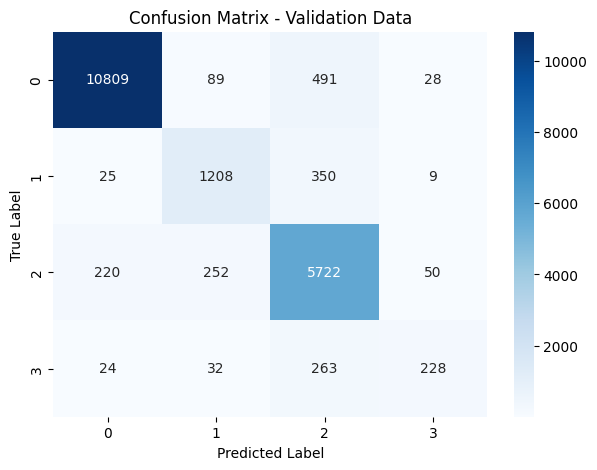

   Class     TP     TN    FP   FN
0      0  10809   8114   269  608
1      1   1208  17835   373  384
2      2   5722  12452  1104  522
3      3    228  19166    87  319
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     11417
           1       0.76      0.76      0.76      1592
           2       0.84      0.92      0.88      6244
           3       0.72      0.42      0.53       547

    accuracy                           0.91     19800
   macro avg       0.83      0.76      0.78     19800
weighted avg       0.91      0.91      0.91     19800



In [ ]:
lr = LogisticRegression(max_iter=100)
svm = LinearSVC(max_iter=500)
sgd = SGDClassifier(max_iter=100)

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    verbosity=-1
)

models = {
    "LogReg": lr,
    "SVM": svm,
    "SGD": sgd,
    "LightGBM": lgb_model
}

best_acc = 0
best_model_name = ""
best_model = None

results = []

for name, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred, average="weighted")
    rec = recall_score(y_val, pred, average="weighted")
    f1 = f1_score(y_val, pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model

results_df = pd.DataFrame(results)
print(results_df)
print("Best Model:", best_model_name)

val_pred = best_model.predict(X_val)

val_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_val, val_pred),
        precision_score(y_val, val_pred, average="weighted"),
        recall_score(y_val, val_pred, average="weighted"),
        f1_score(y_val, val_pred, average="weighted")
    ]
})

print("Validation Metrics")
print(val_metrics)

val_cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(val_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Validation Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

cm = val_cm
n_classes = cm.shape[0]

rows = []
for i in range(n_classes):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)

    rows.append({
        "Class": i,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

tp_tn_df = pd.DataFrame(rows)
print(tp_tn_df)

print(classification_report(y_val, val_pred))

In [ ]:
final_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=96,
    max_depth=8,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

final_model.fit(X_train, y)

print("Predicting test data...")
test_pred = final_model.predict(X_test)

Predicting test data...


In [ ]:
print("Creating submission file...")

submission = pd.read_csv(f"{data_dir}/Sample.csv")

submission["label"] = test_pred

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully")

Creating submission file...
submission.csv created successfully


Validation Metrics
      Metric     Score
0   Accuracy  0.969444
1  Precision  0.971121
2     Recall  0.969444
3   F1-score  0.969757


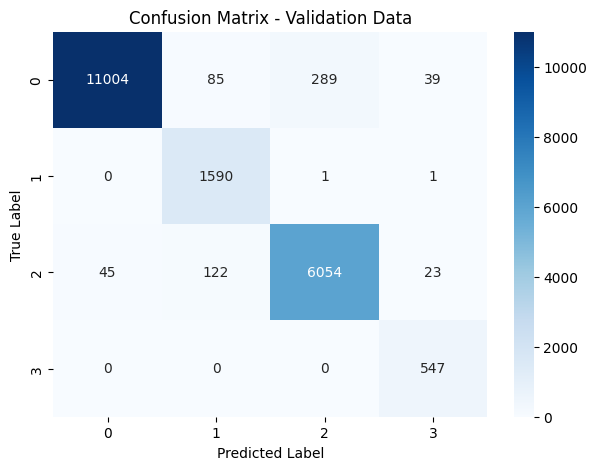

   Class     TP     TN   FP   FN
0      0  11004   8338   45  413
1      1   1590  18001  207    2
2      2   6054  13266  290  190
3      3    547  19190   63    0
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     11417
           1       0.88      1.00      0.94      1592
           2       0.95      0.97      0.96      6244
           3       0.90      1.00      0.95       547

    accuracy                           0.97     19800
   macro avg       0.93      0.98      0.96     19800
weighted avg       0.97      0.97      0.97     19800



In [ ]:
val_pred = final_model.predict(X_val)

val_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_val, val_pred),
        precision_score(y_val, val_pred, average="weighted"),
        recall_score(y_val, val_pred, average="weighted"),
        f1_score(y_val, val_pred, average="weighted")
    ]
})

print("Validation Metrics")
print(val_metrics)

val_cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(val_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Validation Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

cm = val_cm
n_classes = cm.shape[0]

rows = []
for i in range(n_classes):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)

    rows.append({
        "Class": i,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

tp_tn_df = pd.DataFrame(rows)
print(tp_tn_df)

print(classification_report(y_val, val_pred))